# Statistiques descriptives - Base GDELT GKG (2015 → aujourd'hui)

Ce notebook explore la base Parquet hebdomadaire produite par `gdelt_weekly_pipeline.py`.

**Rappel du schéma de chaque fichier `gdelt_YYYY-MM.parquet` :**

| Colonne | Description |
|---|---|
| `GKGRECORDID` | identifiant unique de l'enregistrement GKG |
| `DATE` | horodatage GDELT au format `YYYYMMDDHHMMSS` |
| `SourceCollectionIdentifier` | canal de collecte GDELT (1=WEB, 2=CITATIONONLY - d'après la documentation GDELT) |
| `DocumentIdentifier` | URL de l'article source |
| `SourceCommonName_ID` | identifiant entier du média, à mapper via `gdelt_sources_mapping.json` |
| `EnhancedThemes` | thèmes GKG (format `THEME,offset;THEME,offset;...`) |
| `EnhancedLocations` | lieux géolocalisés détectés |
| `Persons` | personnes citées (séparées par `;`) |
| `Organizations` | organisations citées (séparées par `;`) |
| `Tone` | tonalité moyenne de l'article (échelle GDELT, -100 à +100) |
| `WordCount` | nombre de mots approximatif de l'article |
| `IsTranslingual` | 1 si l'article provient de la master list translingue, 0 sinon |
| `TranslationInfo` | infos de traduction (si article non anglophone) |


**DuckDB** : interroger directement les fichiers Parquet sans tout charger en RAM 
    
**pandas/matplotlib/seaborn** : agrégations plus fines et visualisations


## 1. Installation, imports and loadings

In [1]:
import os
import gc

os.environ["OMP_NUM_THREADS"] = "2"
os.environ["MKL_NUM_THREADS"] = "2"
os.environ["OPENBLAS_NUM_THREADS"] = "2"
os.environ["NUMEXPR_NUM_THREADS"] = "2"

In [2]:
import glob
import json
from pathlib import Path
import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, HTML
import matplotlib.dates as mdates
import plotly.express as px
                                
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")
                               
DATA_DIR = Path("/data/gdelt/gdelt_parquet_db")
SOURCE_MAP_PATH = Path("/data/gdelt/gdelt_sources_mapping.json")

parquet_files = sorted(glob.glob(str(DATA_DIR / "gdelt_*.parquet")))
print(f"✔ {len(parquet_files)} fichiers parquet trouvés ({(sum(os.path.getsize(f) for f in parquet_files) / (1024**3)):.2f} Go).")
                                  
con = duckdb.connect()
# BRIDAGE DUCKDB : On laisse respirer le système d'exploitation et Scikit-Learn
con.execute("PRAGMA memory_limit='32GB'")
con.execute("PRAGMA threads=4")

glob_pattern = str(DATA_DIR / "gdelt_*.parquet")
con.execute(f"CREATE OR REPLACE VIEW gkg AS SELECT * FROM read_parquet('{glob_pattern}')")
                               
with open(SOURCE_MAP_PATH, "r", encoding="utf-8") as f:
    source_map = json.load(f)

src_df = pd.DataFrame({
    "SourceCommonName_ID": [int(k) for k in source_map["id_to_source"].keys()],
    "SourceCommonName": list(source_map["id_to_source"].values()),
})
con.register("src_map", src_df)

print("✔ Base Parquet et dictionnaire JSON (src_map) chargés dans DuckDB.")

✔ 137 fichiers parquet trouvés (414.49 Go).
✔ Base Parquet et dictionnaire JSON (src_map) chargés dans DuckDB.


## 2. Nettoyage de la base (Création de `gkg_clean`)
Cette étape applique tous nos filtres de qualité d'un seul coup :
1. Suppression des erreurs de formatage sur les dates et d'un unique ID corrompu connu.
2. Réconciliation des `SourceCommonName_ID` manquants (ID = 0) en extrayant le nom de domaine de l'URL (`DocumentIdentifier`) et en le comparant au dictionnaire officiel.
3. Suppression pure et simple des articles qui n'ont ni ID valide, ni correspondance dans le dictionnaire.
### 2.1. Broken ID and no source 


In [ ]:
print("Création de la vue 'gkg_inter' (Filtrage et réparation des sources)...")

con.execute(r"""
    CREATE OR REPLACE VIEW gkg_inter AS
    
    WITH raw_filtered AS (
        -- 1. Nettoyage initial : dates valides et exclusion des lignes corrompues connues
        SELECT *
        FROM gkg
        WHERE regexp_matches(CAST(DATE AS VARCHAR), '^\d{14}$')
          AND GKGRECORDID != '20210925181500-T1111'
          AND EnhancedThemes IS NOT NULL 
          AND EnhancedThemes != ''
    )
    
    -- 2. Réparation et filtrage du bruit
    SELECT 
        r.* EXCLUDE (SourceCommonName_ID),
        
        -- On recalcule l'ID : si 0, on prend celui du dico, sinon on garde l'original
        CASE 
            WHEN COALESCE(r.SourceCommonName_ID, 0) = 0 THEN m.SourceCommonName_ID
            ELSE r.SourceCommonName_ID
        END AS SourceCommonName_ID
        
    FROM raw_filtered r
    LEFT JOIN src_map m 
      ON RTRIM(regexp_extract(r.DocumentIdentifier, 'https?://(?:www\.)?([^/?:]+)', 1), '.') = m.SourceCommonName
      
    -- 3. On élimine le bruit (IPs brutes ou sources inconnues du dictionnaire)
    WHERE COALESCE(r.SourceCommonName_ID, 0) != 0 
       OR m.SourceCommonName_ID IS NOT NULL
""")

print("Nettoyage terminé, la vue 'gkg_inter' est prête.")


In [ ]:
def generer_statistiques(con, table_name="gkg_inter", col_source="domain", col_date="date"):
    """
    Génère un tableau de bord de statistiques descriptives réutilisable pour n'importe quelle vue GDELT.
    """
    
    # Extraction de l'année robuste : fonctionne si 'date' est un entier (20210512) ou un vrai TIMESTAMP
    year_expr = f"CAST(SUBSTRING(CAST({col_date} AS VARCHAR), 1, 4) AS INTEGER)"
    
    query = f"""
    -- 1. VOLUMÉTRIE GLOBALE
    SELECT '1. Volumétrie' AS Categorie, 'Nombre total d''articles' AS Indicateur, 
           CAST(COUNT(*) AS VARCHAR) AS Valeur, 'ℹ️' AS Statut 
    FROM {table_name}
    
    UNION ALL
    SELECT '1. Volumétrie', 'Nombre de sources uniques', 
           CAST(COUNT(DISTINCT {col_source}) AS VARCHAR), 'ℹ️' 
    FROM {table_name}
    
    UNION ALL
    SELECT '1. Volumétrie', 'Nombre moyen d''articles par source', 
           CAST(ROUND(COUNT(*) / CAST(COUNT(DISTINCT {col_source}) AS FLOAT), 1) AS VARCHAR), 'ℹ️' 
    FROM {table_name}

    -- 2. DYNAMIQUE TEMPORELLE
    UNION ALL
    SELECT '2. Dynamique Temporelle', 'Nombre moyen de sources actives par an', 
           CAST(ROUND(AVG(nb_src), 1) AS VARCHAR), 'ℹ️' 
    FROM (
        SELECT {year_expr} AS yr, COUNT(DISTINCT {col_source}) AS nb_src 
        FROM {table_name} 
        GROUP BY {year_expr}
    ) AS sub_sources_year

    UNION ALL
    SELECT '2. Dynamique Temporelle', 'Nombre moyen d''articles par an et par source', 
           CAST(ROUND(AVG(nb_arts), 1) AS VARCHAR), 'ℹ️' 
    FROM (
        SELECT {col_source}, {year_expr}, COUNT(*) AS nb_arts 
        FROM {table_name} 
        GROUP BY {col_source}, {year_expr}
    ) AS sub_arts_year

    -- 3. PÉRENNITÉ DES SOURCES
    UNION ALL
    SELECT '3. Pérennité', 'Répartition des sources selon le nb d''années d''activité', 
           STRING_AGG(nb_yrs || ' an(s): ' || nb_src || ' sources', '  |  ' ORDER BY nb_yrs), 'ℹ️' 
    FROM (
        SELECT nb_yrs, COUNT(*) AS nb_src 
        FROM (
            SELECT {col_source}, COUNT(DISTINCT {year_expr}) AS nb_yrs 
            FROM {table_name} 
            GROUP BY {col_source}
        ) AS sub_count_years
        GROUP BY nb_yrs
    ) AS sub_dist_years
    
    ORDER BY Categorie, Indicateur;
    """
    
    # Exécution de la requête
    df_stats = con.execute(query).df()
    
    # Application du style comme dans votre code
    styled_dashboard = df_stats.style.set_properties(**{'text-align': 'left'}, subset=['Categorie', 'Indicateur', 'Valeur'])\
                                     .set_properties(**{'text-align': 'center'}, subset=['Statut'])\
                                     .set_caption(f"<b>Statistiques descriptives - Table/Vue : {table_name}</b>")\
                                     .hide(axis="index")
    return styled_dashboard

In [ ]:
print("Génération pour gkg_inter...")
display(generer_statistiques(con, table_name="gkg_inter", col_source="SourceCommonName_ID", col_date="date"))

### 2.2. Sources with years > 1 

In [ ]:
MIN_ACTIVE_YEARS = 2

print(f"⏳ Création de la vue 'gkg_year' (Filtrage : >= {MIN_ACTIVE_YEARS} ans d'activité)...")

query_year_view = f"""
    CREATE OR REPLACE VIEW gkg_year AS
    
    WITH ValidSources AS (
        -- On identifie les sources qui ont publié sur au moins X années distinctes
        SELECT SourceCommonName_ID
        FROM gkg_inter
        GROUP BY SourceCommonName_ID
        HAVING COUNT(DISTINCT substr(CAST(DATE AS VARCHAR), 1, 4)) >= {MIN_ACTIVE_YEARS}
    )
    -- On filtre en faisant une jointure interne
    SELECT s.*
    FROM gkg_inter s
    INNER JOIN ValidSources v 
      ON s.SourceCommonName_ID = v.SourceCommonName_ID
"""

con.execute(query_year_view)

print(f"Vue 'gkg_year' créée")


In [ ]:
print("Génération pour gkg_year...")
display(generer_statistiques(con, table_name="gkg_year", col_source="SourceCommonName_ID", col_date="date"))

### 2.3. Wikidata (inner and outer)

In [ ]:
print("Création de la vue 'gkg_wiki' (Dans gkg_year ET dans Wikidata)...")


query_year_wiki = r"""
    CREATE OR REPLACE VIEW gkg_wiki AS
    SELECT 
        s.*,
        w.medialabel,
        w.typelabel,
        w.countrylabel,
        w.inception
    FROM gkg_year s
    INNER JOIN (
        -- On classe les métadonnées et on ne garde STRICTEMENT que la ligne 1 pour chaque ID
        SELECT 
            id AS Src_ID, 
            medialabel, 
            typelabel, 
            countrylabel, 
            inception
        FROM read_parquet('data/domains/domains_*.parquet')
        QUALIFY ROW_NUMBER() OVER (PARTITION BY id ORDER BY inception ASC, countrylabel ASC) = 1
    ) w ON s.SourceCommonName_ID = w.Src_ID;
"""

con.execute(query_year_wiki)

print("Vue 'gkg_wiki' créée avec succès !")


print("Création de la vue 'gkg_not_in_wiki' (Dans gkg_year mais PAS dans Wikidata)...")

query_year_not_in_wiki = r"""
    CREATE OR REPLACE VIEW gkg_not_in_wiki AS
    SELECT 
        s.*,
        NULL AS medialabel,
        NULL AS typelabel,
        NULL AS countrylabel,
        NULL AS inception
    FROM gkg_year s
    LEFT JOIN (
        SELECT DISTINCT id AS Src_ID
        FROM read_parquet('data/domains/domains_*.parquet')
    ) w ON s.SourceCommonName_ID = w.Src_ID
    WHERE w.Src_ID IS NULL;
"""

con.execute(query_year_not_in_wiki)
print("Vue 'gkg_not_in_wiki' créée avec succès !")

In [ ]:
print("Génération pour gkg_wiki...")
display(generer_statistiques(con, table_name="gkg_wiki", col_source="SourceCommonName_ID", col_date="date"))

In [ ]:
print("Génération pour gkg_not_in_wiki...")
display(generer_statistiques(con, table_name="gkg_not_in_wiki", col_source="SourceCommonName_ID", col_date="date"))

## 3. Wikidata whitelist compared study

### 3.1. Statistical behavior -- compute 

In [ ]:
import pandas as pd

print("⏳ [Wiki 1/4] Calcul des agrégations de base et du wordcount...")

con.execute("""
    -- 1. Table des métriques globales par source (Wordcount, Thèmes/art, Volume)
    CREATE OR REPLACE TABLE wiki_base_stats AS
    SELECT 
        SourceCommonName_ID,
        COUNT(*) AS total_articles,
        LN(1 + COUNT(*)) AS log_total_articles,
        
        -- Wordcount : Moyenne et CV entre articles
        AVG(WordCount) AS mean_wordcount,
        CASE WHEN AVG(WordCount) > 0 
             THEN STDDEV(WordCount) / AVG(WordCount) 
             ELSE 0 END AS cv_wordcount,
        
        -- Nombre moyen de thèmes DISTINCTS par article (en ignorant les offsets)
        AVG(CASE 
            WHEN EnhancedThemes IS NULL OR EnhancedThemes = '' THEN 0 
            ELSE len(list_distinct(list_transform(string_split(EnhancedThemes, ';'), x -> split_part(x, ',', 1))))
        END) AS mean_themes_per_art

    FROM gkg_not_in_wiki
    GROUP BY SourceCommonName_ID;
""")

print("⏳ [Wiki 1/4 - suite] Agrégation quotidienne pour les séries temporelles...")
con.execute("""
    -- 2. Table des volumes quotidiens (ultra légère en RAM)
    CREATE OR REPLACE TABLE wiki_daily_counts AS
    SELECT 
        SourceCommonName_ID, 
        strptime(substr(CAST(DATE AS VARCHAR), 1, 8), '%Y%m%d')::DATE AS period, 
        COUNT(*) AS n_articles
    FROM gkg_not_in_wiki
    GROUP BY 1, 2;
""")

print("✔ Cellule 1 terminée ! (Base stats et Daily counts créés)")

In [ ]:
print(
    "⏳ [Wiki 2/4] Calcul de la dispersion temporelle (Jours, Mois, Années)..."
)

con.execute("""
    CREATE OR REPLACE TABLE wiki_temporal_stats AS
    WITH daily_stats AS (
        SELECT 
            SourceCommonName_ID,
            COUNT(*) AS active_days,             
            MIN(period) AS first_seen,
            MAX(period) AS last_seen
        FROM wiki_daily_counts
        GROUP BY 1
    ),
    
    -- MOIS : Agrégation et somme des carrés
    monthly_counts AS (
        SELECT SourceCommonName_ID, date_trunc('month', period) AS month_date, SUM(n_articles) AS n_articles
        FROM wiki_daily_counts
        GROUP BY 1, 2
    ),
    monthly_stats AS (
        SELECT 
            SourceCommonName_ID,
            SUM(n_articles) AS sum_x,
            SUM(n_articles * n_articles) AS sum_x2,
            MIN(month_date) AS first_month,
            MAX(month_date) AS last_month
        FROM monthly_counts
        GROUP BY 1
    ),
    monthly_calc AS (
        SELECT 
            SourceCommonName_ID,
            date_diff('month', first_month, last_month) + 1 AS lifespan_months,
            sum_x::DOUBLE / (date_diff('month', first_month, last_month) + 1) AS avg_monthly,
            (sum_x2::DOUBLE / (date_diff('month', first_month, last_month) + 1)) 
            - POW(sum_x::DOUBLE / (date_diff('month', first_month, last_month) + 1), 2) AS var_monthly
        FROM monthly_stats
    ),
                            
    -- ANNEE : Agrégation et somme des carrés
    yearly_counts AS (
        SELECT SourceCommonName_ID, date_trunc('year', period) AS year_date, SUM(n_articles) AS n_articles
        FROM wiki_daily_counts
        GROUP BY 1, 2
    ),
    yearly_stats AS (
        SELECT 
            SourceCommonName_ID,
            COUNT(DISTINCT year_date) AS years_active, -- Le vrai nombre d'années avec au moins 1 article
            SUM(n_articles) AS sum_x,
            SUM(n_articles * n_articles) AS sum_x2,
            MIN(year_date) AS first_year,
            MAX(year_date) AS last_year
        FROM yearly_counts
        GROUP BY 1
    ),
    yearly_calc AS (
        SELECT 
            SourceCommonName_ID,
            years_active,
            date_diff('year', first_year, last_year) + 1 AS lifespan_years,
            sum_x::DOUBLE / (date_diff('year', first_year, last_year) + 1) AS avg_yearly,
            (sum_x2::DOUBLE / (date_diff('year', first_year, last_year) + 1)) 
            - POW(sum_x::DOUBLE / (date_diff('year', first_year, last_year) + 1), 2) AS var_yearly
        FROM yearly_stats
    )

    -- Assemblage temporel
    SELECT 
        d.SourceCommonName_ID,
        yc.years_active,
        
        -- Zero Inflation Rate : 1 - (Jours actifs / Duree de vie en jours)
        1.0 - (d.active_days::DOUBLE / NULLIF(date_diff('day', d.first_seen, d.last_seen) + 1, 0)) AS zero_inflation_rate,
        
        -- CV Mensuel
        CASE WHEN mc.avg_monthly > 0 
             THEN SQRT(GREATEST(mc.var_monthly, 0)) / mc.avg_monthly 
             ELSE 0 END AS cv_monthly,
             
        -- CV Annuel
        CASE WHEN yc.avg_yearly > 0 
             THEN SQRT(GREATEST(yc.var_yearly, 0)) / yc.avg_yearly 
             ELSE 0 END AS cv_yearly

    FROM daily_stats d
    JOIN monthly_calc mc ON d.SourceCommonName_ID = mc.SourceCommonName_ID
    JOIN yearly_calc yc ON d.SourceCommonName_ID = yc.SourceCommonName_ID;
""")

# Nettoyage immédiat de la table quotidienne pour libérer la RAM !
con.execute("DROP TABLE wiki_daily_counts;")
print("✔ Cellule 2 terminée ! (Dynamique temporelle calculée, RAM libérée)")

In [ ]:
print(
    "⏳ [Wiki 3/4] Agrégation des thèmes et calcul de l'entropie de Shannon..."
)

con.execute("""
    -- 1. On compte les occurrences de chaque thème par source (découpage ultra rapide)
    CREATE OR REPLACE TABLE wiki_theme_counts AS
    SELECT 
        SourceCommonName_ID,
        split_part(raw_theme, ',', 1) AS theme,
        COUNT(*) as freq
    FROM (
        SELECT SourceCommonName_ID, unnest(string_split(EnhancedThemes, ';')) AS raw_theme
        FROM gkg_not_in_wiki
        WHERE EnhancedThemes IS NOT NULL AND EnhancedThemes != ''
    )
    WHERE raw_theme != ''
    GROUP BY 1, 2;
""")

con.execute("""
    -- 2. Calcul de l'entropie normalisée sur la table compressée
    CREATE OR REPLACE TABLE wiki_entropy AS
    WITH source_totals AS (
        SELECT SourceCommonName_ID, SUM(freq) as total_freq
        FROM wiki_theme_counts
        GROUP BY 1
    ),
    global_max AS (
        SELECT COUNT(DISTINCT theme) as T_global FROM wiki_theme_counts
    )
    SELECT 
        tc.SourceCommonName_ID,
        SUM(- (tc.freq * 1.0 / st.total_freq) * ln(tc.freq * 1.0 / st.total_freq)) / ln(NULLIF((SELECT T_global FROM global_max), 1)) AS h_norm_themes
    FROM wiki_theme_counts tc
    JOIN source_totals st ON tc.SourceCommonName_ID = st.SourceCommonName_ID
    GROUP BY tc.SourceCommonName_ID;
""")

# Nettoyage de la table des thèmes
con.execute("DROP TABLE wiki_theme_counts;")
print("✔ Cellule 3 terminée ! (Entropie calculée, RAM libérée)")

In [ ]:
print("⏳ [Wiki 4/4] Assemblage de la table finale et export Parquet...")

# On assemble tout dans un DataFrame Pandas
df_wiki_features = con.execute("""
    SELECT 
        b.SourceCommonName_ID,
        0 AS is_wiki,
        t.years_active,
        b.log_total_articles,
        t.cv_monthly,
        t.cv_yearly,
        t.zero_inflation_rate,
        b.mean_wordcount,
        b.cv_wordcount,
        b.mean_themes_per_art,
        COALESCE(e.h_norm_themes, 0) AS h_norm_themes
        
    FROM wiki_base_stats b
    JOIN wiki_temporal_stats t ON b.SourceCommonName_ID = t.SourceCommonName_ID
    LEFT JOIN wiki_entropy e ON b.SourceCommonName_ID = e.SourceCommonName_ID
    ORDER BY b.total_articles DESC;
""").df()

# Sauvegarde en Parquet
df_wiki_features.to_parquet("features_sources_not_in_wiki.parquet", index=False)
print(
    f"✔ EXPORT REUSSI : 'features_sources_not_in_wiki.parquet' ({len(df_wiki_features):,} sources sauvegardées)"
)

# GRAND NETTOYAGE DUCKDB
con.execute(
    "DROP TABLE wiki_base_stats; DROP TABLE wiki_temporal_stats; DROP TABLE wiki_entropy;"
)
print("🧹 Base de données DuckDB nettoyée. Prêt pour la suite !")

In [ ]:
import os
import gc
import pandas as pd

print("⏳ [Wiki 1/4] Scan de gkg_wiki et calcul du ratio 'ECON' dans DuckDB...")

con.execute("""
    CREATE OR REPLACE TABLE wiki_eco_temp AS
    WITH theme_expansion AS (
        SELECT SourceCommonName_ID, unnest(string_split(EnhancedThemes, ';')) AS raw_theme
        FROM gkg_wiki
        WHERE EnhancedThemes IS NOT NULL AND EnhancedThemes != ''
    ),
    clean_themes AS (
        SELECT SourceCommonName_ID, split_part(raw_theme, ',', 1) AS theme
        FROM theme_expansion 
        WHERE raw_theme != ''
    )
    SELECT 
        SourceCommonName_ID,
        -- Ratio basé strictement sur la présence de la chaîne 'ECON'
        SUM(CASE WHEN theme LIKE '%ECON%' THEN 1 ELSE 0 END)::DOUBLE / NULLIF(COUNT(*), 0) AS ratio_eco
    FROM clean_themes
    GROUP BY SourceCommonName_ID;
""")

print("⏳ [Wiki 2/4] Sauvegarde dans un parquet provisoire et nettoyage DuckDB...")
df_eco_wiki = con.execute("SELECT SourceCommonName_ID, ratio_eco FROM wiki_eco_temp").df()
con.execute("DROP TABLE wiki_eco_temp;") # Libération immédiate de la RAM moteur

# Export temporaire sur le disque
df_eco_wiki.to_parquet("temp_eco_wiki.parquet", index=False)
del df_eco_wiki
gc.collect()

print("⏳ [Wiki 3/4] Chargement du fichier de features et fusion...")
df_features_wiki = pd.read_parquet("features_sources_wiki.parquet")
df_temp_eco = pd.read_parquet("temp_eco_wiki.parquet")

# Sécurité : suppression de la colonne si elle existait déjà lors d'un test précédent
if 'ratio_eco' in df_features_wiki.columns:
    df_features_wiki = df_features_wiki.drop(columns=['ratio_eco'])

# Jointure par la gauche pour conserver toutes tes sources d'origine
df_features_wiki = df_features_wiki.merge(df_temp_eco, on='SourceCommonName_ID', how='left').fillna({'ratio_eco': 0.0})

print("⏳ [Wiki 4/4] Écrasement (overwrite) du fichier Parquet final...")
df_features_wiki.to_parquet("features_sources_wiki.parquet", index=False)

# Suppression du fichier temporaire et nettoyage final de la RAM
os.remove("temp_eco_wiki.parquet")
del df_features_wiki, df_temp_eco
gc.collect()

print("✔ WIKI TERMINÉ : 'features_sources_wiki.parquet' est mis à jour avec le ratio_eco !")

In [ ]:
print("⏳ [Not-Wiki 1/4] Scan de gkg_not_in_wiki et calcul du ratio 'ECON' dans DuckDB...")

con.execute("""
    CREATE OR REPLACE TABLE not_wiki_eco_temp AS
    WITH theme_expansion AS (
        SELECT SourceCommonName_ID, unnest(string_split(EnhancedThemes, ';')) AS raw_theme
        FROM gkg_not_in_wiki
        WHERE EnhancedThemes IS NOT NULL AND EnhancedThemes != ''
    ),
    clean_themes AS (
        SELECT SourceCommonName_ID, split_part(raw_theme, ',', 1) AS theme
        FROM theme_expansion 
        WHERE raw_theme != ''
    )
    SELECT 
        SourceCommonName_ID,
        SUM(CASE WHEN theme LIKE '%ECON%' THEN 1 ELSE 0 END)::DOUBLE / NULLIF(COUNT(*), 0) AS ratio_eco
    FROM clean_themes
    GROUP BY SourceCommonName_ID;
""")

print("⏳ [Not-Wiki 2/4] Sauvegarde dans un parquet provisoire et nettoyage DuckDB...")
df_eco_not_wiki = con.execute("SELECT SourceCommonName_ID, ratio_eco FROM not_wiki_eco_temp").df()
con.execute("DROP TABLE not_wiki_eco_temp;") 

df_eco_not_wiki.to_parquet("temp_eco_not_wiki.parquet", index=False)
del df_eco_not_wiki
gc.collect()

print("⏳ [Not-Wiki 3/4] Chargement du fichier de features et fusion...")
df_features_not_wiki = pd.read_parquet("features_sources_not_in_wiki.parquet")
df_temp_eco = pd.read_parquet("temp_eco_not_wiki.parquet")

if 'ratio_eco' in df_features_not_wiki.columns:
    df_features_not_wiki = df_features_not_wiki.drop(columns=['ratio_eco'])

df_features_not_wiki = df_features_not_wiki.merge(df_temp_eco, on='SourceCommonName_ID', how='left').fillna({'ratio_eco': 0.0})

print("⏳ [Not-Wiki 4/4] Écrasement (overwrite) du fichier Parquet final...")
df_features_not_wiki.to_parquet("features_sources_not_in_wiki.parquet", index=False)

# Suppression du fichier temporaire et nettoyage final de la RAM
os.remove("temp_eco_not_wiki.parquet")
del df_features_not_wiki, df_temp_eco
gc.collect()

print("✔ NOT-WIKI TERMINÉ : 'features_sources_not_in_wiki.parquet' est mis à jour avec le ratio_eco !")

In [ ]:
import numpy as np
import pandas as pd

print(
    "⏳ [Mission 1/4] Calcul et ajout de 'log_total_articles_year' dans les"
    " parquets..."
)

for file_name in [
    "features_sources_wiki.parquet",
    "features_sources_not_in_wiki.parquet",
]:
  df = pd.read_parquet(file_name)

  # 1. On retrouve le nombre total d'articles exact : exp(log_total_articles) - 1
  total_articles = np.expm1(df["log_total_articles"]).round()

  # 2. Calcul du log de la moyenne par année active : LN(1 + total_articles / years_active)
  # Remplacement de 0 par NaN pour éviter toute division par zéro, puis fillna(0.0)
  df["log_total_articles_year"] = np.log1p(
      total_articles / df["years_active"].replace(0, np.nan)
  ).fillna(0.0)

  # 3. Sauvegarde dans le parquet (on garde log_total_articles pour l'instant, on le supprime à la cellule suivante)
  df.to_parquet(file_name, index=False)
  print(f"✔ 'log_total_articles_year' ajouté avec succès dans : {file_name}")

print("✔ Cellule 1 terminée !")

In [ ]:
print(
    "⏳ [Mission 2/4] Suppression de 'log_total_articles' dans les deux"
    " parquets..."
)

for file_name in [
    "features_sources_wiki.parquet",
    "features_sources_not_in_wiki.parquet",
]:
  df = pd.read_parquet(file_name)

  if "log_total_articles" in df.columns:
    df = df.drop(columns=["log_total_articles"])
    df.to_parquet(file_name, index=False)
    print(
        f"✔ Colonne 'log_total_articles' supprimée avec succès dans :"
        f" {file_name}"
    )
  else:
    print(f"ℹ Colonne déjà absente dans : {file_name}")

print("✔ Cellule 2 terminée !")

In [ ]:
print(
    "⏳ [Mission 3/4] Renommage de 'zero_inflation_rate' en"
    " 'inactive_days_rate'..."
)

for file_name in [
    "features_sources_wiki.parquet",
    "features_sources_not_in_wiki.parquet",
]:
  df = pd.read_parquet(file_name)

  if "zero_inflation_rate" in df.columns:
    df = df.rename(columns={"zero_inflation_rate": "inactive_days_rate"})
    df.to_parquet(file_name, index=False)
    print(f"✔ Renommage effectué avec succès dans : {file_name}")
  elif "inactive_days_rate" in df.columns:
    print(
        f"ℹ La colonne s'appelle déjà 'inactive_days_rate' dans : {file_name}"
    )
  else:
    print(f"⚠ Colonne 'zero_inflation_rate' introuvable dans : {file_name}")

print("✔ Cellule 3 terminée !")

In [ ]:
import gc
import os
import pandas as pd

print("🚀 [Turbo Mode] Débridage temporaire de DuckDB (100 Go RAM / 32 threads)...")
con.execute("PRAGMA memory_limit='100GB'")
con.execute("PRAGMA threads=32")

# ====================================================
# PARTIE A : WIKI
# ====================================================
print("⏳ [Wiki 1/4] Extraction des thèmes économiques (ECON) avec pré-filtrage...")

con.execute("""
    CREATE OR REPLACE TABLE eco_theme_counts_wiki AS
    WITH theme_expansion AS (
        SELECT SourceCommonName_ID, unnest(string_split(EnhancedThemes, ';')) AS raw_theme
        FROM gkg_wiki
        -- 🔥 OPTIMISATION : On ne découpe que les articles qui parlent d'économie !
        WHERE EnhancedThemes LIKE '%ECON%'
    ),
    clean_themes AS (
        SELECT SourceCommonName_ID, split_part(raw_theme, ',', 1) AS theme
        FROM theme_expansion 
        WHERE raw_theme != ''
    )
    SELECT 
        SourceCommonName_ID,
        theme,
        COUNT(*) as freq
    FROM clean_themes
    WHERE theme LIKE '%ECON%'
    GROUP BY 1, 2;
""")

print("⏳ [Wiki 2/4] Calcul de la sous-entropie normalisée (h_norm_eco)...")
con.execute("""
    CREATE OR REPLACE TABLE wiki_eco_entropy AS
    WITH source_totals AS (
        SELECT SourceCommonName_ID, SUM(freq) as total_freq
        FROM eco_theme_counts_wiki
        GROUP BY 1
    ),
    global_max AS (
        SELECT COUNT(DISTINCT theme) as T_global FROM eco_theme_counts_wiki
    )
    SELECT 
        tc.SourceCommonName_ID,
        SUM(- (tc.freq * 1.0 / st.total_freq) * ln(tc.freq * 1.0 / st.total_freq)) / NULLIF(ln(NULLIF((SELECT T_global FROM global_max), 1)), 0) AS h_norm_eco
    FROM eco_theme_counts_wiki tc
    JOIN source_totals st ON tc.SourceCommonName_ID = st.SourceCommonName_ID
    GROUP BY tc.SourceCommonName_ID;
""")

print("⏳ [Wiki 3/4] Export temporaire et nettoyage RAM DuckDB...")
df_eco_wiki = con.execute(
    "SELECT SourceCommonName_ID, h_norm_eco FROM wiki_eco_entropy"
).df()
con.execute("DROP TABLE eco_theme_counts_wiki; DROP TABLE wiki_eco_entropy;")

df_eco_wiki.to_parquet("temp_h_eco_wiki.parquet", index=False)
del df_eco_wiki
gc.collect()

print("⏳ [Wiki 4/4] Fusion avec features_sources_wiki.parquet...")
df_features_wiki = pd.read_parquet("features_sources_wiki.parquet")
df_temp_eco = pd.read_parquet("temp_h_eco_wiki.parquet")

if "h_norm_eco" in df_features_wiki.columns:
  df_features_wiki = df_features_wiki.drop(columns=["h_norm_eco"])

df_features_wiki = df_features_wiki.merge(
    df_temp_eco, on="SourceCommonName_ID", how="left"
).fillna({"h_norm_eco": 0.0})
df_features_wiki.to_parquet("features_sources_wiki.parquet", index=False)

os.remove("temp_h_eco_wiki.parquet")
del df_features_wiki, df_temp_eco
gc.collect()
print("✔ WIKI TERMINÉ : 'h_norm_eco' ajouté avec succès !")

# ====================================================
# PARTIE B : NOT-WIKI
# ====================================================
print(
    "\n⏳ [Not-Wiki 1/4] Extraction des thèmes économiques (ECON) avec pré-filtrage..."
)

con.execute("""
    CREATE OR REPLACE TABLE eco_theme_counts_not_wiki AS
    WITH theme_expansion AS (
        SELECT SourceCommonName_ID, unnest(string_split(EnhancedThemes, ';')) AS raw_theme
        FROM gkg_not_in_wiki
        -- 🔥 OPTIMISATION : Même pré-filtrage ici pour diviser la charge CPU
        WHERE EnhancedThemes LIKE '%ECON%'
    ),
    clean_themes AS (
        SELECT SourceCommonName_ID, split_part(raw_theme, ',', 1) AS theme
        FROM theme_expansion 
        WHERE raw_theme != ''
    )
    SELECT 
        SourceCommonName_ID,
        theme,
        COUNT(*) as freq
    FROM clean_themes
    WHERE theme LIKE '%ECON%'
    GROUP BY 1, 2;
""")

print(
    "⏳ [Not-Wiki 2/4] Calcul de la sous-entropie normalisée (h_norm_eco)..."
)
con.execute("""
    CREATE OR REPLACE TABLE not_wiki_eco_entropy AS
    WITH source_totals AS (
        SELECT SourceCommonName_ID, SUM(freq) as total_freq
        FROM eco_theme_counts_not_wiki
        GROUP BY 1
    ),
    global_max AS (
        SELECT COUNT(DISTINCT theme) as T_global FROM eco_theme_counts_not_wiki
    )
    SELECT 
        tc.SourceCommonName_ID,
        SUM(- (tc.freq * 1.0 / st.total_freq) * ln(tc.freq * 1.0 / st.total_freq)) / NULLIF(ln(NULLIF((SELECT T_global FROM global_max), 1)), 0) AS h_norm_eco
    FROM eco_theme_counts_not_wiki tc
    JOIN source_totals st ON tc.SourceCommonName_ID = st.SourceCommonName_ID
    GROUP BY tc.SourceCommonName_ID;
""")

print("⏳ [Not-Wiki 3/4] Export temporaire et nettoyage RAM DuckDB...")
df_eco_not_wiki = con.execute(
    "SELECT SourceCommonName_ID, h_norm_eco FROM not_wiki_eco_entropy"
).df()
con.execute(
    "DROP TABLE eco_theme_counts_not_wiki; DROP TABLE not_wiki_eco_entropy;"
)

df_eco_not_wiki.to_parquet("temp_h_eco_not_wiki.parquet", index=False)
del df_eco_not_wiki
gc.collect()

print("⏳ [Not-Wiki 4/4] Fusion avec features_sources_not_in_wiki.parquet...")
df_features_not_wiki = pd.read_parquet("features_sources_not_in_wiki.parquet")
df_temp_eco = pd.read_parquet("temp_h_eco_not_wiki.parquet")

if "h_norm_eco" in df_features_not_wiki.columns:
  df_features_not_wiki = df_features_not_wiki.drop(columns=["h_norm_eco"])

df_features_not_wiki = df_features_not_wiki.merge(
    df_temp_eco, on="SourceCommonName_ID", how="left"
).fillna({"h_norm_eco": 0.0})
df_features_not_wiki.to_parquet(
    "features_sources_not_in_wiki.parquet", index=False
)

os.remove("temp_h_eco_not_wiki.parquet")
del df_features_not_wiki, df_temp_eco
gc.collect()

print("🛑 [Eco Mode] Retour aux limites courtoises pour le serveur partagé (32 Go RAM / 4 threads)...")
con.execute("PRAGMA memory_limit='32GB'")
con.execute("PRAGMA threads=4")

print("✔ NOT-WIKI TERMINÉ : 'h_norm_eco' ajouté avec succès dans les 2 parquets !")
print("🚀 Toutes les missions sont complétées en temps record ! Fichiers Parquet 100% à jour.")

In [ ]:
import gc
import os
import pandas as pd

print(
    "🚀 [Turbo Mode] Débridage temporaire de DuckDB pour le scan quotidien (64"
    " Go RAM / 16 threads)..."
)
con.execute("PRAGMA memory_limit='64GB'")
con.execute("PRAGMA threads=16")

# ====================================================
# PARTIE A : WIKI
# ====================================================
print("⏳ [Wiki 1/4] Agrégation quotidienne et somme des carrés dans DuckDB...")

con.execute("""
    CREATE OR REPLACE TABLE wiki_cv_daily_temp AS
    WITH daily_counts AS (
        SELECT 
            SourceCommonName_ID, 
            strptime(substr(CAST(DATE AS VARCHAR), 1, 8), '%Y%m%d')::DATE AS period, 
            COUNT(*) AS n_articles
        FROM gkg_wiki
        GROUP BY 1, 2
    ),
    daily_stats AS (
        SELECT 
            SourceCommonName_ID,
            SUM(n_articles) AS sum_x,
            SUM(n_articles * n_articles) AS sum_x2,
            MIN(period) AS first_seen,
            MAX(period) AS last_seen
        FROM daily_counts
        GROUP BY 1
    ),
    daily_calc AS (
        SELECT 
            SourceCommonName_ID,
            date_diff('day', first_seen, last_seen) + 1 AS lifespan_days,
            sum_x::DOUBLE / NULLIF(date_diff('day', first_seen, last_seen) + 1, 0) AS avg_daily,
            (sum_x2::DOUBLE / NULLIF(date_diff('day', first_seen, last_seen) + 1, 0)) 
            - POW(sum_x::DOUBLE / NULLIF(date_diff('day', first_seen, last_seen) + 1, 0), 2) AS var_daily
        FROM daily_stats
    )
    SELECT 
        SourceCommonName_ID,
        -- Calcul du CV quotidien réel (avec jours à 0 intégrés via la variance)
        CASE WHEN avg_daily > 0 
             THEN SQRT(GREATEST(var_daily, 0)) / avg_daily 
             ELSE 0 END AS cv_daily
    FROM daily_calc;
""")

print("⏳ [Wiki 2/4] Sauvegarde temporaire et nettoyage RAM DuckDB...")
df_cv_wiki = con.execute(
    "SELECT SourceCommonName_ID, cv_daily FROM wiki_cv_daily_temp"
).df()
con.execute("DROP TABLE wiki_cv_daily_temp;")

df_cv_wiki.to_parquet("temp_cv_daily_wiki.parquet", index=False)
del df_cv_wiki
gc.collect()

print("⏳ [Wiki 3/4] Fusion avec features_sources_wiki.parquet...")
df_features_wiki = pd.read_parquet("features_sources_wiki.parquet")
df_temp_cv = pd.read_parquet("temp_cv_daily_wiki.parquet")

if "cv_daily" in df_features_wiki.columns:
  df_features_wiki = df_features_wiki.drop(columns=["cv_daily"])

df_features_wiki = df_features_wiki.merge(
    df_temp_cv, on="SourceCommonName_ID", how="left"
).fillna({"cv_daily": 0.0})
df_features_wiki.to_parquet("features_sources_wiki.parquet", index=False)

os.remove("temp_cv_daily_wiki.parquet")
del df_features_wiki, df_temp_cv
gc.collect()
print("✔ WIKI TERMINÉ : 'cv_daily' (avec jours à 0) ajouté avec succès !")

# ====================================================
# PARTIE B : NOT-WIKI
# ====================================================
print(
    "\n⏳ [Not-Wiki 1/4] Agrégation quotidienne et somme des carrés dans"
    " DuckDB..."
)

con.execute("""
    CREATE OR REPLACE TABLE not_wiki_cv_daily_temp AS
    WITH daily_counts AS (
        SELECT 
            SourceCommonName_ID, 
            strptime(substr(CAST(DATE AS VARCHAR), 1, 8), '%Y%m%d')::DATE AS period, 
            COUNT(*) AS n_articles
        FROM gkg_not_in_wiki
        GROUP BY 1, 2
    ),
    daily_stats AS (
        SELECT 
            SourceCommonName_ID,
            SUM(n_articles) AS sum_x,
            SUM(n_articles * n_articles) AS sum_x2,
            MIN(period) AS first_seen,
            MAX(period) AS last_seen
        FROM daily_counts
        GROUP BY 1
    ),
    daily_calc AS (
        SELECT 
            SourceCommonName_ID,
            date_diff('day', first_seen, last_seen) + 1 AS lifespan_days,
            sum_x::DOUBLE / NULLIF(date_diff('day', first_seen, last_seen) + 1, 0) AS avg_daily,
            (sum_x2::DOUBLE / NULLIF(date_diff('day', first_seen, last_seen) + 1, 0)) 
            - POW(sum_x::DOUBLE / NULLIF(date_diff('day', first_seen, last_seen) + 1, 0), 2) AS var_daily
        FROM daily_stats
    )
    SELECT 
        SourceCommonName_ID,
        CASE WHEN avg_daily > 0 
             THEN SQRT(GREATEST(var_daily, 0)) / avg_daily 
             ELSE 0 END AS cv_daily
    FROM daily_calc;
""")

print("⏳ [Not-Wiki 2/4] Sauvegarde temporaire et nettoyage RAM DuckDB...")
df_cv_not_wiki = con.execute(
    "SELECT SourceCommonName_ID, cv_daily FROM not_wiki_cv_daily_temp"
).df()
con.execute("DROP TABLE not_wiki_cv_daily_temp;")

df_cv_not_wiki.to_parquet("temp_cv_daily_not_wiki.parquet", index=False)
del df_cv_not_wiki
gc.collect()

print("⏳ [Not-Wiki 3/4] Fusion avec features_sources_not_in_wiki.parquet...")
df_features_not_wiki = pd.read_parquet("features_sources_not_in_wiki.parquet")
df_temp_cv = pd.read_parquet("temp_cv_daily_not_wiki.parquet")

if "cv_daily" in df_features_not_wiki.columns:
  df_features_not_wiki = df_features_not_wiki.drop(columns=["cv_daily"])

df_features_not_wiki = df_features_not_wiki.merge(
    df_temp_cv, on="SourceCommonName_ID", how="left"
).fillna({"cv_daily": 0.0})
df_features_not_wiki.to_parquet(
    "features_sources_not_in_wiki.parquet", index=False
)

os.remove("temp_cv_daily_not_wiki.parquet")
del df_features_not_wiki, df_temp_cv
gc.collect()

print(
    "🛑 [Eco Mode] Retour aux limites courtoises pour le serveur partagé (32 Go"
    " RAM / 4 threads)..."
)
con.execute("PRAGMA memory_limit='32GB'")
con.execute("PRAGMA threads=4")

print(
    "✔ NOT-WIKI TERMINÉ : 'cv_daily' ajouté avec succès dans les 2 parquets !"
)
print("🚀 Vous avez désormais une mesure exacte de la dispersion quotidienne !")

In [ ]:
import gc
import os
import pandas as pd

print(
    "🚀 [Turbo Mode] Débridage temporaire de DuckDB pour le comptage (64"
    " Go RAM / 16 threads)..."
)
con.execute("PRAGMA memory_limit='64GB'")
con.execute("PRAGMA threads=16")

# ====================================================
# PARTIE A : WIKI
# ====================================================
print("⏳ [Wiki] Comptage exact du nombre total d'articles...")

con.execute("""
    CREATE OR REPLACE TABLE wiki_total_counts AS
    SELECT SourceCommonName_ID, COUNT(*) AS total_articles
    FROM gkg_wiki
    GROUP BY 1;
""")

df_count_wiki = con.execute("SELECT * FROM wiki_total_counts").df()
con.execute("DROP TABLE wiki_total_counts;")

print("⏳ [Wiki] Fusion avec features_sources_wiki.parquet...")
df_features_wiki = pd.read_parquet("features_sources_wiki.parquet")

# Sécurité si la colonne existe déjà suite à un test précédent
if "total_articles" in df_features_wiki.columns:
  df_features_wiki = df_features_wiki.drop(columns=["total_articles"])

# Jointure et sauvegarde
df_features_wiki = df_features_wiki.merge(
    df_count_wiki, on="SourceCommonName_ID", how="left"
).fillna({"total_articles": 0})
df_features_wiki.to_parquet("features_sources_wiki.parquet", index=False)

del df_count_wiki, df_features_wiki
gc.collect()
print("✔ WIKI TERMINÉ : 'total_articles' ajouté avec succès !")

# ====================================================
# PARTIE B : NOT-WIKI
# ====================================================
print("\n⏳ [Not-Wiki] Comptage exact du nombre total d'articles...")

con.execute("""
    CREATE OR REPLACE TABLE not_wiki_total_counts AS
    SELECT SourceCommonName_ID, COUNT(*) AS total_articles
    FROM gkg_not_in_wiki
    GROUP BY 1;
""")

df_count_not_wiki = con.execute("SELECT * FROM not_wiki_total_counts").df()
con.execute("DROP TABLE not_wiki_total_counts;")

print("⏳ [Not-Wiki] Fusion avec features_sources_not_in_wiki.parquet...")
df_features_not_wiki = pd.read_parquet("features_sources_not_in_wiki.parquet")

if "total_articles" in df_features_not_wiki.columns:
  df_features_not_wiki = df_features_not_wiki.drop(columns=["total_articles"])

df_features_not_wiki = df_features_not_wiki.merge(
    df_count_not_wiki, on="SourceCommonName_ID", how="left"
).fillna({"total_articles": 0})
df_features_not_wiki.to_parquet(
    "features_sources_not_in_wiki.parquet", index=False
)

del df_count_not_wiki, df_features_not_wiki
gc.collect()

print(
    "🛑 [Eco Mode] Retour aux limites courtoises pour le serveur partagé (32 Go"
    " RAM / 4 threads)..."
)
con.execute("PRAGMA memory_limit='32GB'")
con.execute("PRAGMA threads=4")

print(
    "✔ NOT-WIKI TERMINÉ : 'total_articles' ajouté avec succès dans les 2"
    " parquets !"
)

### 3.2. Filtering through Wiki

We want to :

1) identify the statistical behvaior of key sources that we know are relevant to be part of our sample

2) eventually define thresholds on certain features and study the relevance of the sample it allows us to extract within the wikidata database

3) if relevant, extend these threshold to select non wikidata sources and check if relevant 

In [3]:
df_wiki = pd.read_parquet("features_sources_wiki.parquet")
df_not_wiki = pd.read_parquet("features_sources_not_in_wiki.parquet")
df_wiki = df_wiki[df_wiki["total_articles"] > 0 ] 

# Configuration esthétique globale
sns.set_theme(style="whitegrid")
plt.rcParams["font.family"] = "sans-serif"

# 1. Ajout d'une étiquette explicite pour la superposition (légende)
df_wiki["source_type"] = "1. Wiki"
df_not_wiki["source_type"] = "2. Not-Wiki"

#### 3.2.1. Whitelist behavior 

In [36]:
import re
import numpy as np
import pandas as pd

# ====================================================
# 1. LISTE DE RÉFÉRENCE ("GOLD STANDARD" MÉDIATIQUE)
# ====================================================
sites_reconnus = [
    # ==========================================================
    # 1. PRESSE ÉCONOMIQUE & FINANCIÈRE (Internationale & FR)
    # ==========================================================
    "wsj.com",
    "nytimes.com",
    "washingtonpost.com",
    "chicagotribune.com",
    "telegraph.co.uk",
    "theglobeandmail.com",
    "ft.com",
    "theguardian.com",
    "latimes.com",
    "usatoday.com",
    "bloomberg.com",
    "reuters.com",
    "economist.com",
    "forbes.com",
    "nikkei.com",  # Japon (Référence économique asiatique)
    "handelsblatt.com",  # Allemagne (Référence économique DACH)
    "ilsole24ore.com",  # Italie (Référence économique)
    "cincodias.elpais.com",  # Espagne (Éco)
    "expansion.com",  # Espagne (Éco)
    "financialpost.com",  # Canada (Éco)
    "lesechos.fr",
    "latribune.fr",
    "challenges.fr",
    "lemonde.fr",
    "capital.fr",
    "lecho.be",  # Belgique (Référence économique)
    "agefi.com",  # Suisse (Éco)
    # ==========================================================
    # 2. AGENCES DE PRESSE & FLUX CONTINUS (Le standard du rythme)
    # ==========================================================
    "apnews.com",
    "afp.com",
    # ==========================================================
    # 3. PRESSE GÉNÉRALISTE ANGLOPHONE MAJEURE (US / UK / Global)
    # ==========================================================
    "bbc.co.uk",
    "bbc.com",
    "cnn.com",
    "time.com",
    "thetimes.co.uk",
    "smh.com.au",  # The Sydney Morning Herald (Australie)
    "torontostar.com",  # Canada
    "scmp.com",  # South China Morning Post
    "thehindu.com",  # Inde (Référence anglophone)
    # ==========================================================
    # 4. PRESSE GÉNÉRALISTE INTERNATIONALE (Europe & LatAm)
    # ==========================================================
    "elpais.com",
    "elmundo.es",
    "spiegel.de",
    "zeit.de",
    "sueddeutsche.de",
    "faz.net",  # Frankfurter Allgemeine Zeitung
    "corriere.it",
    "repubblica.it",
    "lastampa.it",
    "clarin.com",  # Argentine
    "lanacion.com.ar",  # Argentine
    "oglobo.globo.com",  # Brésil
    "eluniversal.com.mx",  # Mexique
    # ==========================================================
    # 5. PRESSE GÉNÉRALISTE FRANCOPHONE (France / Régions)
    # ==========================================================
    "lefigaro.fr",
    "liberation.fr",
    "leparisien.fr",
    "la-croix.com",
    "lexpress.fr",
    "lepoint.fr",
    "nouvelobs.com",
    "20minutes.fr",
    "courrierinternational.com",
    "franceinfo.fr",
    "ouest-france.fr",  # Plus grand tirage de la PQR
    "sudouest.fr",
    "lavoixdunord.fr",
    # ==========================================================
    # 6. PRESSE GÉNÉRALISTE FRANCOPHONE (Canada, Suisse, Bel, Afrique)
    # ==========================================================
    "lorientlejour.com",  # Liban
    "elwatan.com",  # Algérie (Référence francophone)
    "le360.ma",  # Maroc
]

print("Chargement des données Parquet et extraction stricte...")

# 2. Chargement et fusion des parquets
df_wiki = pd.read_parquet("features_sources_wiki.parquet")
df_not_wiki = pd.read_parquet("features_sources_not_in_wiki.parquet")

df_wiki["Origine"] = "Wiki"
df_not_wiki["Origine"] = "Not-Wiki"
df_all = pd.concat([df_wiki, df_not_wiki], ignore_index=True)

# 3. Ré-injection de la colonne texte SourceCommonName si absente
if "SourceCommonName" not in df_all.columns:
  if "src_df" in globals():
    df_all = df_all.merge(src_df, on="SourceCommonName_ID", how="left")
    df_all["SourceCommonName"] = df_all["SourceCommonName"].fillna(
        df_all["SourceCommonName_ID"].astype(str)
    )
  else:
    raise ValueError(
        "Erreur : 'src_df' est introuvable pour traduire les IDs en noms !"
    )

# 4. 🔥 REGEX STRICTE : Refuse les sous-domaines (ex: madame.lefigaro.fr -> REJETÉ)
# /^ (www\.)? site $/ impose le début et la fin exacte du domaine
pattern = "|".join(
    [r"^(www\.)?" + re.escape(site) + r"$" for site in sites_reconnus]
)

df_gold = df_all[
    df_all["SourceCommonName"]
    .str.lower()
    .str.contains(pattern, na=False, regex=True)
].copy()

# 5. DÉCOUVERTE ET ORGANISATION DU TOUT-INCLUS (Toutes les colonnes disponibles)
# On classe les colonnes par blocs logiques pour que le tableau soit lisible
blocs_logiques = {
    "Meta": ["SourceCommonName", "Origine", "SourceCommonName_ID", "is_wiki"],
    "Volume & Longévité": [
        "total_articles",
        "log_total_articles_year",
        "years_active",
    ],
    "Dispersion & Régularité": [
        "inactive_days_rate",
        "cv_daily",
        "cv_monthly",
        "cv_yearly",
    ],
    "Style Éditorial": [
        "mean_wordcount",
        "cv_wordcount",
        "mean_themes_per_art",
    ],
    "Sémantique & Économie": ["h_norm_themes", "ratio_eco", "h_norm_eco"],
}

# On rassemble toutes les colonnes dans l'ordre des blocs (en gardant uniquement celles qui existent)
cols_ordonnees = []
for bloc, cols in blocs_logiques.items():
  cols_ordonnees.extend([c for c in cols if c in df_gold.columns])

# On ajoute à la fin les éventuelles colonnes surprises qui n'étaient pas dans notre liste
cols_restantes = [c for c in df_gold.columns if c not in cols_ordonnees]
cols_finales = cols_ordonnees + cols_restantes

df_gold = (
    df_gold[cols_finales]
    .sort_values(by="ratio_eco", ascending=False)
)

print(
    f"\n TABLEAU DE BORD STRICT ({len(df_gold)} médias légitimes — sous-domaines"
    " purgés) :\n"
    + "=" * 90
)

# 6. DICTIONNAIRE DE FORMATAGE UNIVERSEL
format_dict = {
    "total_articles": "{:,.0f}",
    "log_total_articles_year": "{:.2f}",
    "years_active": "{:.1f}",
    "inactive_days_rate": "{:.1%}",
    "cv_daily": "{:.2f}",
    "cv_monthly": "{:.2f}",
    "cv_yearly": "{:.2f}",
    "cv_wordcount": "{:.2f}",
    "mean_wordcount": "{:,.0f}",
    "mean_themes_per_art": "{:.2f}",
    "ratio_eco": "{:.1%}",
    "h_norm_eco": "{:.2f}",
    "h_norm_themes": "{:.2f}",
}

# 7. 🔥 APPLICATION DE CODE COULEUR PAR BLOC SÉMANTIQUE (Chaining Pandas Styler)
styler = df_gold.style.format(format_dict, na_rep="-")

# Bloc 1 : Volume & Longévité -> Nuances de Bleu (Plus c'est foncé, plus le volume/longévité est élevé)
styler = styler.background_gradient(
    subset=[
        c
        for c in ["total_articles", "log_total_articles_year", "years_active"]
        if c in df_gold.columns
    ],
    cmap="Blues",
)

# Bloc 2 : Jours inactifs -> Nuances de Rouge (0% = Blanc, taux élevé = Rouge alerte)
if "inactive_days_rate" in df_gold.columns:
  styler = styler.background_gradient(
      subset=["inactive_days_rate"], cmap="OrRd", vmin=0, vmax=0.3
  )

# Bloc 3 : Coefficients de variation -> Nuances Orange/Chaud (Plus le CV est haut = erratique = Orange foncé)
styler = styler.background_gradient(
    subset=[
        c
        for c in ["cv_daily", "cv_monthly", "cv_yearly", "cv_wordcount"]
        if c in df_gold.columns
    ],
    cmap="YlOrBr",
    vmin=0,
    vmax=2.0,
)

# Bloc 4 : Style & Diversité globale -> Nuances de Violet / Teal
styler = styler.background_gradient(
    subset=[
        c
        for c in ["mean_wordcount", "mean_themes_per_art", "h_norm_themes"]
        if c in df_gold.columns
    ],
    cmap="PuBu",
)

# Bloc 5 : Spécialisation Économique -> Nuances de Vert (Vert intense = pure player économique)
styler = styler.background_gradient(
    subset=[
        c for c in ["ratio_eco", "h_norm_eco"] if c in df_gold.columns
    ],
    cmap="YlGn",
    vmin=0,
    vmax=1.0,
)

# Fixation du style du nom de source pour le rendre bien visible à gauche
styler = styler.set_properties(
    subset=["SourceCommonName"],
    **{"font-weight": "bold", "text-align": "left", "background-color": "#f8f9fa"},
)

display(styler)

Chargement des données Parquet et extraction stricte...

 TABLEAU DE BORD STRICT (64 médias légitimes — sous-domaines purgés) :


/tmp/ipykernel_2776/3822827466.py:127: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  .str.contains(pattern, na=False, regex=True)


,SourceCommonName,Origine,SourceCommonName_ID,is_wiki,total_articles,log_total_articles_year,years_active,inactive_days_rate,cv_daily,cv_monthly,cv_yearly,mean_wordcount,cv_wordcount,mean_themes_per_art,h_norm_themes,ratio_eco,h_norm_eco
11541,agefi.com,Not-Wiki,25781,0,"31,480",8.28,8.0,34.0%,1.05,0.73,0.67,350,0.96,20.69,0.55,12.8%,0.48
183,bloomberg.com,Wiki,262,1,"460,372",10.55,12.0,17.1%,1.22,1.00,0.93,352,1.07,25.39,0.57,12.8%,0.52
7739,financialpost.com,Not-Wiki,2527,0,"87,415",8.89,12.0,4.4%,0.78,0.46,0.42,622,0.89,33.78,0.56,12.7%,0.48
317,nikkei.com,Wiki,2071,1,"351,808",10.29,12.0,0.4%,0.63,0.50,0.46,483,1.03,26.78,0.54,11.5%,0.43
206,handelsblatt.com,Wiki,8877,1,"432,559",10.49,12.0,19.3%,0.78,0.60,0.55,379,1.03,22.24,0.55,10.9%,0.47
5,reuters.com,Wiki,175,1,"3,362,549",12.54,12.0,5.3%,1.03,0.88,0.89,370,0.76,29.66,0.58,10.2%,0.51
6314,capital.fr,Not-Wiki,14139,0,"155,071",9.47,12.0,10.6%,0.71,0.47,0.40,398,0.71,23.94,0.55,9.5%,0.44
346,expansion.com,Wiki,26954,1,"338,274",10.25,12.0,0.5%,0.67,0.50,0.48,366,0.82,19.99,0.56,9.1%,0.44
62,forbes.com,Wiki,306,1,"768,676",11.07,12.0,1.2%,0.53,0.31,0.28,780,1.14,29.03,0.58,8.9%,0.42
537,ilsole24ore.com,Wiki,9037,1,"248,058",10.02,11.0,24.6%,0.83,0.72,0.68,355,0.87,19.67,0.55,8.7%,0.44


h_norm_themes is always above 0.5 

h_norm_eco is above 0.4, we retain 0.3 for the threshold

ratio_eco is above 0.02, we retain 0.015

years_active is strongly above 7

log_articles_year is above 6.5

In [4]:
df_all = pd.concat([df_wiki, df_not_wiki], ignore_index=True)

In [22]:
df_all.describe()

,SourceCommonName_ID,is_wiki,years_active,cv_monthly,cv_yearly,inactive_days_rate,mean_wordcount,cv_wordcount,mean_themes_per_art,h_norm_themes,ratio_eco,log_total_articles_year,h_norm_eco,cv_daily,total_articles
count,"130,059.00","130,059.00","130,059.00","130,059.00","130,059.00","130,059.00","130,059.00","130,059.00","130,059.00","130,059.00","130,059.00","130,059.00","130,059.00","130,059.00","130,059.00"
mean,"125,261.59",0.04,4.76,1.67,0.72,0.82,561.57,0.70,21.83,0.42,0.04,3.32,0.22,7.17,"11,000.27"
std,"85,649.50",0.20,3.27,1.13,0.46,0.27,741.68,0.44,13.03,0.11,0.06,2.57,0.15,6.39,"98,836.62"
min,1.00,0.00,2.00,0.00,0.00,0.00,4.56,0.00,2.00,0.00,0.00,0.69,0.00,0.00,0.00
25%,"40,180.50",0.00,2.00,0.89,0.41,0.79,273.06,0.44,12.80,0.35,0.01,1.25,0.10,2.46,6.00
50%,"124,406.00",0.00,3.00,1.38,0.68,0.96,413.87,0.64,19.85,0.44,0.03,2.40,0.24,5.43,35.00
75%,"195,684.50",0.00,7.00,2.12,0.97,0.99,634.29,0.87,27.85,0.51,0.05,4.90,0.35,9.72,742.00
max,"299,425.00",1.00,12.00,10.78,3.31,1.00,"95,975.00",14.10,308.00,0.61,1.00,14.43,0.59,54.24,"22,224,485.00"


In [5]:
# 1. LE SOCLE STRUCTUREL (Obligatoire pour tout le monde : ET)

cond_structure = (df_all["years_active"] >= 4.0) & (
    df_all["log_total_articles_year"] >= 6.5
)

# 2. PROFIL A : La Presse Quotidienne Généraliste
# Forte diversité globale + au moins 1,5 % d'économie (pour éviter la presse 100% sport ou pop-culture)
cond_generaliste = (df_all["h_norm_themes"] >= 0.50) & (
    df_all["ratio_eco"] >= 0.02
)

# 3. PROFIL B : La Presse Économique Spécialisée (L'exception de rattrapage)
# Même si h_norm_themes < 0.50, on le garde SI c'est un média concentré sur l'éco AVEC une forte diversité interne
cond_eco_niche = (df_all["ratio_eco"] >= 0.1) & (
    df_all["h_norm_eco"] >= 0.35
)

# --- APPLICATION DU OU LOGIQUE STRATÉGIQUE ---
# Le média doit passer le test structurel ET (être Généraliste OU être Spécialisé Éco)
df_propre = df_all[cond_structure & (cond_generaliste | cond_eco_niche)].copy()

In [40]:
df_propre.describe()

,SourceCommonName_ID,is_wiki,years_active,cv_monthly,cv_yearly,inactive_days_rate,mean_wordcount,cv_wordcount,mean_themes_per_art,h_norm_themes,ratio_eco,log_total_articles_year,h_norm_eco,cv_daily,total_articles
count,"13,667.00","13,667.00","13,667.00","13,667.00","13,667.00","13,667.00","13,667.00","13,667.00","13,667.00","13,667.00","13,667.00","13,667.00","13,667.00","13,667.00","13,667.00"
mean,"46,422.40",0.22,9.80,0.86,0.73,0.28,412.89,0.90,23.70,0.54,0.04,8.26,0.40,1.20,"84,754.12"
std,"62,101.49",0.41,2.46,0.60,0.40,0.22,194.78,0.42,7.64,0.02,0.03,1.13,0.06,0.93,"217,377.05"
min,1.00,0.00,4.00,0.12,0.06,0.00,24.43,0.11,3.78,0.36,0.02,6.50,0.09,0.15,"2,662.00"
25%,"6,699.50",0.00,8.00,0.51,0.45,0.09,299.35,0.70,18.55,0.53,0.03,7.33,0.37,0.76,"13,764.50"
50%,"26,401.00",0.00,11.00,0.73,0.65,0.24,384.41,0.82,22.83,0.55,0.03,8.14,0.41,1.01,"32,963.00"
75%,"35,813.00",0.00,12.00,1.03,0.90,0.42,488.56,0.99,28.05,0.56,0.04,9.08,0.44,1.37,"87,404.00"
max,"279,599.00",1.00,12.00,10.75,3.31,0.97,"9,240.67",14.10,81.08,0.61,0.38,13.63,0.58,23.64,"9,942,046.00"


In [42]:
df_propre.sort_values(by="total_articles", ascending=False).head(50)

,SourceCommonName_ID,is_wiki,years_active,cv_monthly,cv_yearly,inactive_days_rate,mean_wordcount,cv_wordcount,mean_themes_per_art,h_norm_themes,ratio_eco,log_total_articles_year,h_norm_eco,cv_daily,total_articles,Origine
0,81,1,12,0.41,0.37,0.00,622.07,1.58,24.04,0.57,0.05,13.63,0.47,0.54,"9,942,046.00",Wiki
5222,36148,0,12,0.56,0.54,0.09,202.08,0.86,12.15,0.54,0.02,13.58,0.38,0.59,"9,511,739.00",Not-Wiki
1,34473,1,12,0.92,0.81,0.01,818.17,1.03,29.91,0.53,0.12,13.16,0.34,1.06,"6,208,211.00",Wiki
2,724,1,12,0.19,0.20,0.00,362.15,0.75,21.88,0.57,0.06,12.93,0.46,0.25,"4,957,871.00",Wiki
3,427,1,9,0.73,0.66,0.00,582.73,1.26,30.36,0.59,0.03,13.06,0.48,0.80,"4,236,616.00",Wiki
4,26651,1,12,0.96,0.89,0.14,195.63,0.50,15.45,0.53,0.03,12.68,0.36,1.03,"3,861,668.00",Wiki
5,175,1,12,0.88,0.89,0.05,369.81,0.76,29.66,0.58,0.10,12.54,0.51,1.03,"3,362,549.00",Wiki
5223,6652,0,12,0.61,0.51,0.01,264.52,1.01,18.99,0.53,0.03,12.53,0.37,0.72,"3,317,775.00",Not-Wiki
5224,3065,0,12,0.20,0.20,0.00,405.47,2.27,19.24,0.55,0.12,12.48,0.44,0.59,"3,171,025.00",Not-Wiki
5225,25682,0,8,0.23,0.22,0.00,530.04,0.91,29.32,0.54,0.07,12.85,0.37,0.29,"3,059,496.00",Not-Wiki


In [6]:
import pandas as pd

# ==============================================================================
# 1. INDIQUEZ ICI LE NOM DE VOTRE DATAFRAME QUI CONTIENT VOS SOURCES RETENUES
# ==============================================================================
df_mes_sources_propres = (
    df_propre  # <-- REMPLACEZ 'df_all' par le nom de votre variable filtrée
)

# On mémorise les ID qui ont survécu à votre tri
ids_retenus = set(df_mes_sources_propres["SourceCommonName_ID"])
print(f"✔ Nombre de sources retenues dans votre sélection : {len(ids_retenus):,}")

# ==============================================================================
# 2. CHARGEMENT AU PROPRE DES DONNÉES D'ORIGINE (Pour éviter tout écrasement)
# ==============================================================================
print("⏳ Comparaison avec les fichiers Parquet originaux...")
df_wiki_orig = pd.read_parquet("features_sources_wiki.parquet")
df_not_orig = pd.read_parquet("features_sources_not_in_wiki.parquet")

df_wiki_orig["Origine"] = "Wiki"
df_not_orig["Origine"] = "Not-Wiki"
df_global_orig = pd.concat([df_wiki_orig, df_not_orig], ignore_index=True)

# 3. Isolation des lignes d'origine dont l'ID N'EST PAS dans votre sélection
df_rejetes = df_global_orig[
    ~df_global_orig["SourceCommonName_ID"].isin(ids_retenus)
].copy()
print(f"✔ Nombre de sources rejetées identifiées : {len(df_rejetes):,}")

# 4. Ré-injection des noms de sites (si nécessaire)
if "SourceCommonName" not in df_rejetes.columns:
  if "src_df" in globals():
    df_rejetes = df_rejetes.merge(src_df, on="SourceCommonName_ID", how="left")
    df_rejetes["SourceCommonName"] = df_rejetes["SourceCommonName"].fillna(
        df_rejetes["SourceCommonName_ID"].astype(str)
    )
  else:
    df_rejetes["SourceCommonName"] = df_rejetes["SourceCommonName_ID"].astype(
        str
    )

# 5. Sélection des colonnes pour le diagnostic
cols_diag = [
    "SourceCommonName",
    "Origine",
    "total_articles",
    "log_total_articles_year",  
    "years_active",
    "inactive_days_rate",
    "cv_daily",
    "ratio_eco",
    "h_norm_eco",
    "h_norm_themes",
    "mean_wordcount",
]
cols_visibles = [col for col in cols_diag if col in df_rejetes.columns]

# 6. Extraction des TOP 50 évincés (triés par volume total d'articles)
top_50_wiki_rejetes = (
    df_rejetes[df_rejetes["Origine"] == "Wiki"]
    .sort_values(by="total_articles", ascending=False)
    .head(50)[cols_visibles]
)

top_50_not_wiki_rejetes = (
    df_rejetes[df_rejetes["Origine"] == "Not-Wiki"]
    .sort_values(by="total_articles", ascending=False)
    .head(50)[cols_visibles]
)

# ==============================================================================
# 7. AFFICHAGE DES RÉSULTATS
# ==============================================================================
format_dict = {
    "total_articles": "{:,.0f}",
    "log_total_articles_year": "{:.2f}",
    "years_active": "{:.2f}",
    "inactive_days_rate": "{:.2%}",
    "cv_daily": "{:.3f}",
    "ratio_eco": "{:.2%}",
    "h_norm_eco": "{:.3f}",
    "h_norm_themes": "{:.3f}",
    "mean_wordcount": "{:,.1f}",
}

print(
    f"\n❌ TOP 50 DES SOURCES WIKI REJETÉES (sur"
    f" {len(df_rejetes[df_rejetes['Origine']=='Wiki']):,} au total) :\n"
    + "=" * 90
)
display(
    top_50_wiki_rejetes.style.format(format_dict, na_rep="-")
    .background_gradient(
        subset=[c for c in ["ratio_eco", "h_norm_themes"] if c in cols_visibles],
        cmap="YlOrRd",
        vmin=0,
        vmax=1,
    )
    .set_properties(
        subset=["SourceCommonName"], **{"font-weight": "bold", "text-align": "left"}
    )
)

print(
    f"\n❌ TOP 50 DES SOURCES NOT-WIKI REJETÉES (sur"
    f" {len(df_rejetes[df_rejetes['Origine']=='Not-Wiki']):,} au total) :\n"
    + "=" * 90
)
display(
    top_50_not_wiki_rejetes.style.format(format_dict, na_rep="-")
    .background_gradient(
        subset=[c for c in ["ratio_eco", "h_norm_themes"] if c in cols_visibles],
        cmap="YlOrRd",
        vmin=0,
        vmax=1,
    )
    .set_properties(
        subset=["SourceCommonName"], **{"font-weight": "bold", "text-align": "left"}
    )
)

✔ Nombre de sources retenues dans votre sélection : 13,667
⏳ Comparaison avec les fichiers Parquet originaux...
✔ Nombre de sources rejetées identifiées : 116,392

❌ TOP 50 DES SOURCES WIKI REJETÉES (sur 2,261 au total) :


,SourceCommonName,Origine,total_articles,log_total_articles_year,years_active,inactive_days_rate,cv_daily,ratio_eco,h_norm_eco,h_norm_themes,mean_wordcount
0,scotcampus.com,Wiki,"947,186",11.82,7.00,97.10%,8.004,1.06%,0.338,0.483,508.5
1,foxnews.com,Wiki,"732,032",11.02,12.00,0.41%,0.449,1.85%,0.465,0.570,441.0
2,bd-pratidin.com,Wiki,"459,362",10.64,11.00,3.51%,0.632,1.74%,0.393,0.515,242.5
3,amarujala.com,Wiki,"445,497",10.52,12.00,6.86%,1.195,5.48%,0.231,0.498,317.8
4,dailystar.co.uk,Wiki,"388,646",10.39,12.00,1.88%,0.457,1.52%,0.362,0.562,392.7
5,nydailynews.com,Wiki,"367,558",10.33,12.00,0.41%,0.764,1.94%,0.479,0.571,399.5
6,informer.rs,Wiki,"350,822",10.37,11.00,1.43%,0.685,1.77%,0.371,0.536,272.6
7,dailyvoice.com,Wiki,"350,585",10.28,12.00,2.42%,0.618,1.29%,0.403,0.520,237.7
8,israelnationalnews.com,Wiki,"322,727",10.29,11.00,13.70%,0.684,1.07%,0.437,0.545,267.3
9,aftonbladet.se,Wiki,"322,000",10.20,12.00,0.43%,0.419,1.45%,0.449,0.522,397.3



❌ TOP 50 DES SOURCES NOT-WIKI REJETÉES (sur 114,131 au total) :


,SourceCommonName,Origine,total_articles,log_total_articles_year,years_active,inactive_days_rate,cv_daily,ratio_eco,h_norm_eco,h_norm_themes,mean_wordcount
2261,iheart.com,Not-Wiki,"22,224,485",14.43,12.00,0.67%,0.614,1.58%,0.407,0.556,216.1
2262,bjhmoh.cn,Not-Wiki,"2,811,391",13.24,5.00,29.00%,1.488,0.68%,0.250,0.427,681.2
2263,tvguide.co.uk,Not-Wiki,"1,909,197",11.98,12.00,49.88%,1.418,0.72%,0.304,0.520,295.0
2264,schoolloop.com,Not-Wiki,"1,464,793",13.10,3.00,0.14%,0.860,0.21%,0.357,0.378,311.8
2265,english.wafa.ps,Not-Wiki,"1,463,830",11.80,11.00,29.04%,1.511,1.94%,0.429,0.500,228.2
2266,joker.com,Not-Wiki,"1,255,580",12.94,3.00,58.43%,1.318,21.31%,0.041,0.253,58.0
2267,dailypolitical.com,Not-Wiki,"1,192,074",11.79,9.00,36.88%,1.266,26.78%,0.301,0.435,669.6
2268,cfi.net.cn,Not-Wiki,"1,171,840",11.49,12.00,1.87%,1.063,15.68%,0.335,0.459,"2,153.7"
2269,krankenkassen-direkt.de,Not-Wiki,"924,033",13.04,2.00,0.00%,0.121,7.00%,0.118,0.356,207.1
2270,wkrb13.com,Not-Wiki,"909,588",11.64,8.00,38.70%,1.350,28.25%,0.307,0.429,658.1


⏳ Génération des histogrammes de densité superposés...


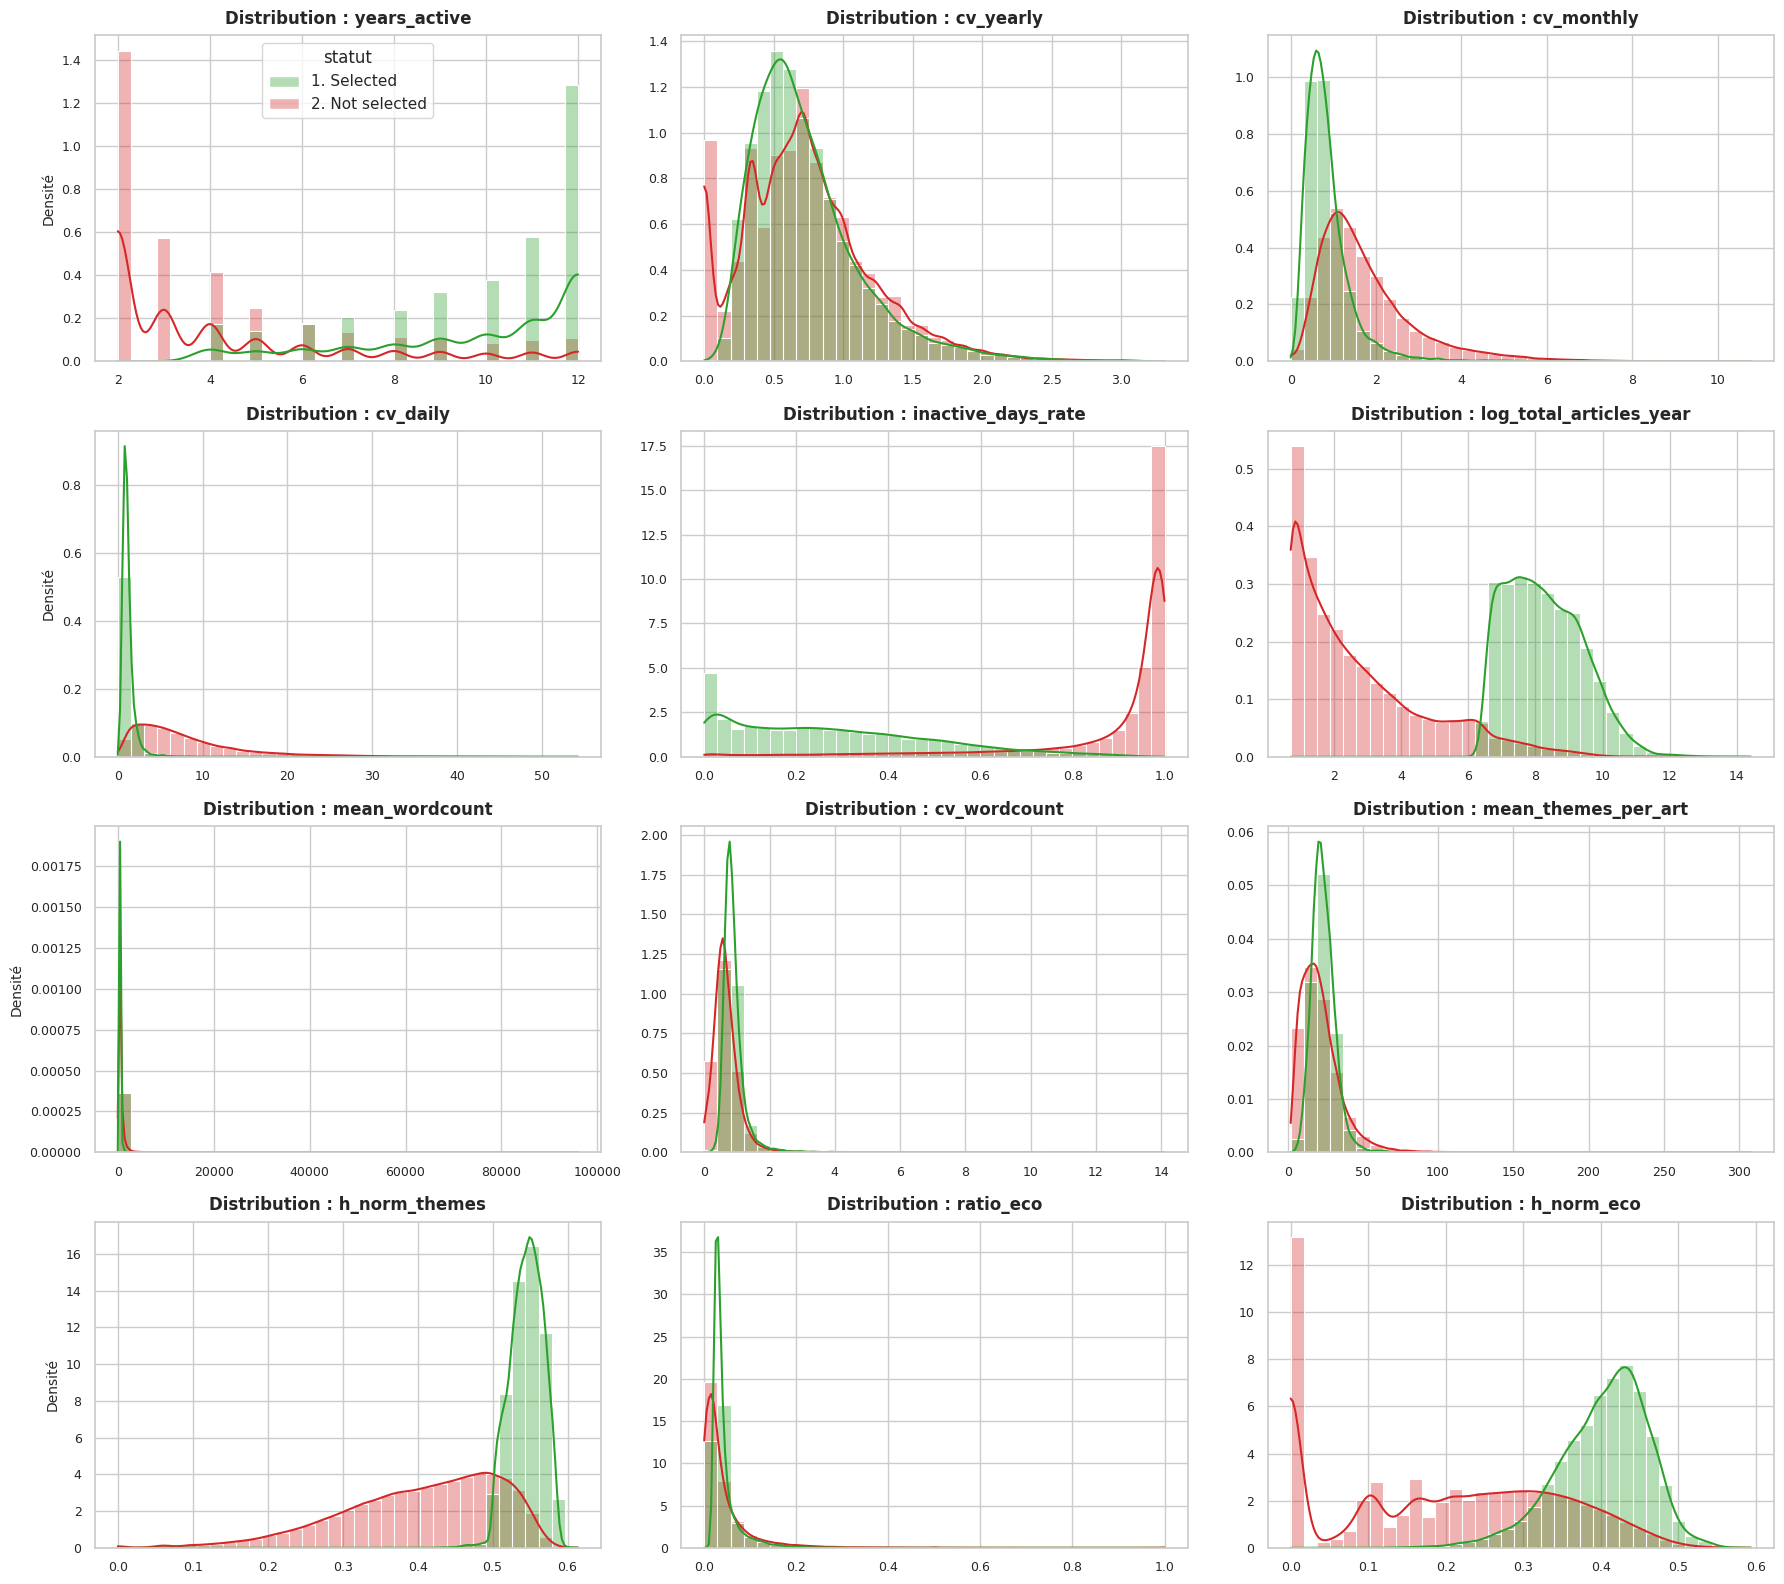

In [47]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# 1. Préparation et étiquetage (INDISPENSABLE pour le paramètre 'hue')
df_propre = df_propre.copy()
df_propre["statut"] = "1. Selected"

df_rejetes = df_rejetes.copy()
df_rejetes["statut"] = "2. Not selected"

# 2. Assemblage dans un DataFrame unique
df_all = pd.concat([df_propre, df_rejetes], ignore_index=True)

# 3. Liste exacte des features comportementales et sémantiques
features_to_plot = [
    "years_active",
    "cv_yearly",
    "cv_monthly",
    "cv_daily",
    "inactive_days_rate",
    "log_total_articles_year",
    "mean_wordcount",
    "cv_wordcount",
    "mean_themes_per_art",
    "h_norm_themes",
    "ratio_eco",
    "h_norm_eco",
]

# 4. Configuration de la grille de sous-graphiques (4 lignes x 3 colonnes)
fig, axes = plt.subplots(4, 3, figsize=(18, 16))
axes = axes.flatten()  # Aplatir le tableau 2D en 1D pour boucler facilement

print("⏳ Génération des histogrammes de densité superposés...")

for i, col in enumerate(features_to_plot):
  ax = axes[i]
  data_visu = df_all
  sns.histplot(
      data=data_visu,
      x=col,
      hue="statut",  # On utilise notre nouvelle colonne d'étiquetage
      stat="density",  # Compare les densités (aires = 1), pas les volumes bruts
      common_norm=False,  # INDISPENSABLE : Normalise les deux groupes séparément
      kde=True,  # Ajoute la courbe lisse continue
      bins=35,
      alpha=0.35,  # Transparence pour voir les intersections
      palette={
          "1. Selected": "#2ca02c",  # Vert pour ce qui est propre/gardé
          "2. Not selected": "#d62728",  # Rouge pour ce qui est exclu
      },
      ax=ax,
      legend=(i == 0),  # On n'affiche la légende que sur le premier graphique
  )

  # Nettoyage et habillage du sous-graphique
  ax.set_title(f"Distribution : {col}", fontsize=12, fontweight="bold", pad=8)
  ax.set_xlabel("")
  ax.set_ylabel("Densité" if i % 3 == 0 else "", fontsize=10)
  ax.tick_params(labelsize=9)

plt.tight_layout()
plt.show()

⏳ Préparation des données Retenues vs Rejetées...
✔ df_rejected recréé automatiquement (116,381 sources).
⏳ Génération de la grille de boxplots (Retenus vs Rejetés)...


/tmp/ipykernel_97862/687875472.py:97: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/clucas/venvs/gdelt/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


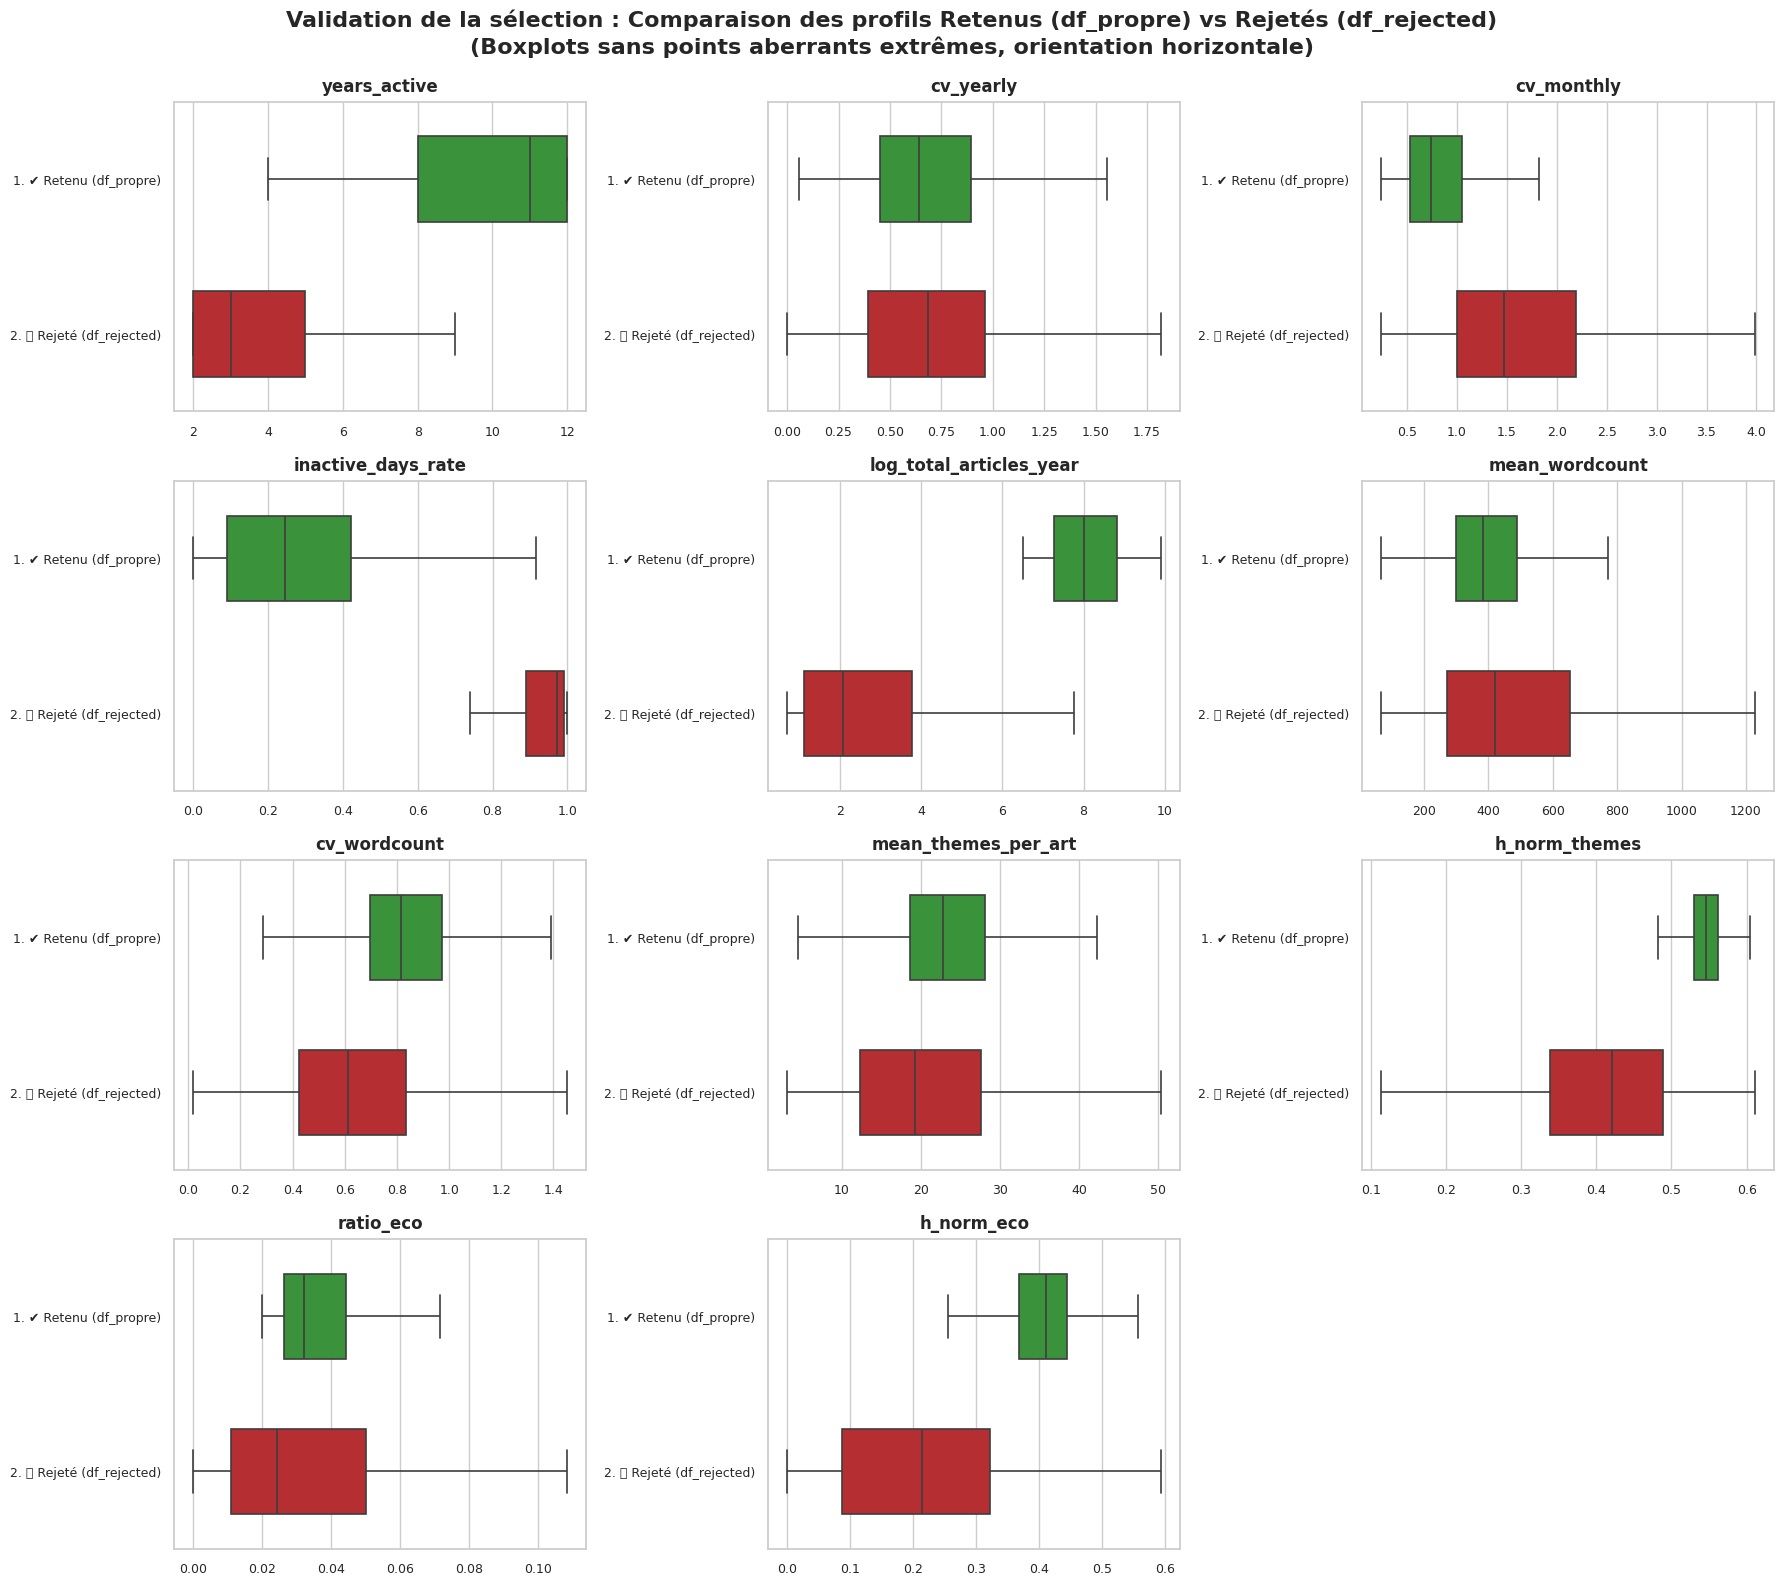

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Configuration esthétique
sns.set_theme(style="whitegrid")
plt.rcParams["font.family"] = "sans-serif"

print("⏳ Préparation des données Retenues vs Rejetées...")

# 1. Sécurité : au cas où df_rejected ne serait pas explicitement en mémoire, on le recrée depuis df_all
if "df_rejected" not in globals():
  ids_retenus = set(df_propre["SourceCommonName_ID"])
  df_rejected = df_all[~df_all["SourceCommonName_ID"].isin(ids_retenus)].copy()
  print(f"✔ df_rejected recréé automatiquement ({len(df_rejected):,} sources).")

# 2. Ajout des étiquettes de statut pour le graphique
df_propre["statut_filtrage"] = "1. ✔ Retenu (df_propre)"
df_rejected["statut_filtrage"] = "2. ❌ Rejeté (df_rejected)"

# 3. Assemblage pour la visualisation
df_plot = pd.concat([df_propre, df_rejected], ignore_index=True)

# 4. Liste exacte de vos 11 features
features_to_plot = [
    "years_active",
    "cv_yearly",
    "cv_monthly",
    "inactive_days_rate",
    "log_total_articles_year",
    "mean_wordcount",
    "cv_wordcount",
    "mean_themes_per_art",
    "h_norm_themes",
    "ratio_eco",
    "h_norm_eco",
]

# Grille 4x3 (100% rendu CPU Matplotlib)
fig, axes = plt.subplots(4, 3, figsize=(18, 16))
axes = axes.flatten()

print("⏳ Génération de la grille de boxplots (Retenus vs Rejetés)...")

for i, col in enumerate(features_to_plot):
  ax = axes[i]

    data_visu = df_plot
  else:
    data_visu = df_plot[(df_plot[col] >= q01) & (df_plot[col] <= q99)]

  # 🔥 BOXPLOT HORIZONTAL SANS EXTRÊMES ABERRANTS
  sns.boxplot(
      data=data_visu,
      x=col,
      y="statut_filtrage",
      hue="statut_filtrage",
      showfliers=False,  # Indispensable : masque les points aberrants extrêmes du Web
      width=0.55,
      linewidth=1.2,
      palette={
          "1. ✔ Retenu (df_propre)": "#2ca02c",  # Vert franc : valide le filtre
          "2. ❌ Rejeté (df_rejected)": (
              "#cb181d"
          ),  # Rouge rouge/brique : montre le bruit évacué
      },
      ax=ax,
      legend=False,
  )

  # Habillage du sous-graphique
  ax.set_title(col, fontsize=12, fontweight="bold", pad=8)
  ax.set_xlabel("")
  ax.set_ylabel("")
  ax.tick_params(labelsize=9)

# Désactivation de la 12ème case vide
axes[11].axis("off")

fig.suptitle(
    (
        "Validation de la sélection : Comparaison des profils Retenus (df_propre)"
        " vs Rejetés (df_rejected)\n(Boxplots sans points aberrants extrêmes,"
        " orientation horizontale)"
    ),
    fontsize=16,
    fontweight="bold",
    y=0.99,
)

plt.tight_layout()
plt.show()

In [8]:
import pandas as pd

# ==============================================================================
# 1. SAUVEGARDE DU DATAFRAME COMPLET (Toutes les features)
# ==============================================================================
output_parquet = "echantillon_medias_economiques_propre.parquet"
output_csv = "echantillon_medias_economiques_propre.csv"

# Sauvegarde au format Parquet (Optimal pour la suite de votre pipeline DuckDB/Pandas)
df_propre.to_parquet(output_parquet, index=False)

# Sauvegarde au format CSV (Pratique pour une lecture rapide dans Excel ou R)
df_propre.to_csv(output_csv, index=False, encoding="utf-8")

print(f"✔ Échantillon complet sauvegardé : {len(df_propre):,} sources.")
print(f"  ↳ Fichier Parquet : {output_parquet}")
print(f"  ↳ Fichier CSV     : {output_csv}\n")

# ==============================================================================
# 2. EXPORT DES LISTES PURES (Pour requêtes SQL ou scrapers externes)
# ==============================================================================
# A. Export d'un fichier texte avec un identifiant GDELT par ligne
liste_ids = df_propre["SourceCommonName_ID"].dropna().unique()
with open("liste_ids_retenus.txt", "w", encoding="utf-8") as f:
  f.write("\n".join(liste_ids.astype(str)))
print(
    f"✔ Liste de {len(liste_ids):,} IDs GDELT exportée ➔ 'liste_ids_retenus.txt'"
)

# B. Export d'un fichier texte avec un nom de domaine par ligne (si la colonne existe)
if "SourceCommonName" in df_propre.columns:
  liste_domaines = (
      df_propre["SourceCommonName"].dropna().astype(str).str.lower().unique()
  )
  with open("liste_sites_retenus.txt", "w", encoding="utf-8") as f:
    f.write("\n".join(sorted(liste_domaines)))
  print(
      f"✔ Liste de {len(liste_domaines):,} noms de domaine exportée ➔"
      " 'liste_sites_retenus.txt'"
  )

✔ Échantillon complet sauvegardé : 13,667 sources.
  ↳ Fichier Parquet : echantillon_medias_economiques_propre.parquet
  ↳ Fichier CSV     : echantillon_medias_economiques_propre.csv

✔ Liste de 13,667 IDs GDELT exportée ➔ 'liste_ids_retenus.txt'
